# Criticality Searches

Criticality searches, or the adjustment of some free parameter of your problem (e.g. boron concentation, control rod insertion point), is a routine part of neutronics. In this example, we'll perform a critical search based on fuel enrichment. OpenMC performs this criticality search using the methodology from Price and Roskoff (https://linkinghub.elsevier.com/retrieve/pii/S014919702300166X), a GRsecant (generalized regressive secant) method. This method takes into account the statistical uncertainty in $k$ and also dynamically adjusts the number of batches run (using more batches as one gets closer to criticality).

In [1]:
import openmc

model = openmc.Model()

In [2]:
uo2 = openmc.Material()
uo2.add_element('U', 1.0, enrichment=3.5)
uo2.add_element('O', 2.0)
uo2.set_density('g/cm3', 10.97)

zirconium = openmc.Material()
zirconium.add_element('Zr', 1.0)
zirconium.set_density('g/cm3', 6.55)

water = openmc.model.borated_water(1500, temperature=600, temp_unit='K', pressure=15, press_unit='MPa')

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

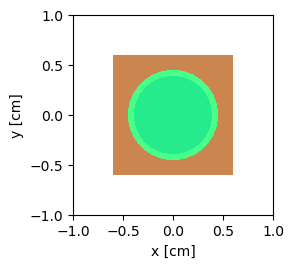

In [3]:
box = openmc.model.RectangularPrism(1.2, 1.2, boundary_type='reflective')
top = openmc.ZPlane(z0=300.0, boundary_type='vacuum')
bottom = openmc.ZPlane(z0=0.0, boundary_type='vacuum')

fuel_surf = openmc.ZCylinder(r=0.39)
clad_surf = openmc.ZCylinder(r=0.45)

fuel = openmc.Cell(region=-fuel_surf & -box, fill=uo2)
clad = openmc.Cell(region=+fuel_surf & -clad_surf & -box, fill=zirconium)
h2o = openmc.Cell(region=+clad_surf & -box, fill=water)

model.geometry = openmc.Geometry(openmc.Universe(cells=[fuel, clad, h2o]))

model.geometry.root_universe.plot(width=(2, 2))

In [4]:
model.settings.particles = 10000
model.settings.inactive = 10
model.settings.batches = 50

In [5]:
def change_enrichment(wo):
    uo2.remove_element('U')
    uo2.add_element('U', 1.0, enrichment=wo)

When running a criticality search, we can specify the desired maximum uncertainty in $k$ with `sigma_final` and the tolerance to which we want $k$ to match unity with `k_tol`.

In [6]:
result = model.keff_search(change_enrichment, x0=1.0, x1=5.0, output=True, k_tol=1e-3, sigma_final=1e-3)

Iteration 1: batches=50, x=1, keff=0.81033+/-0.00108
Iteration 2: batches=50, x=5, keff=1.28987+/-0.00162
Iteration 3: batches=30, x=2.58209, keff=1.12677+/-0.00194
Iteration 4: batches=30, x=2.39262, keff=1.10210+/-0.00259
Iteration 5: batches=30, x=2.31738, keff=1.09917+/-0.00155
Iteration 6: batches=30, x=0.87641, keff=0.76413+/-0.00185
Iteration 7: batches=30, x=1.92971, keff=1.04202+/-0.00221
Iteration 8: batches=30, x=1.87237, keff=1.02585+/-0.00160
Iteration 9: batches=30, x=1.82916, keff=1.02206+/-0.00234
Iteration 10: batches=30, x=1.76715, keff=1.00652+/-0.00152
Iteration 11: batches=30, x=1.73573, keff=1.00629+/-0.00224
Iteration 12: batches=30, x=1.71484, keff=1.00167+/-0.00223
Iteration 13: batches=94, x=1.71226, keff=0.99879+/-0.00102
Iteration 14: batches=112, x=1.71547, keff=0.99920+/-0.00094


## Geometry

Criticality searches work for any change to a mutable object - in this next example, we'll take a sphere of uranium enclosed in a metal aluminum shell of 1 cm thickness, and determine the critical radius.

In [7]:
model = openmc.Model()

fuel = openmc.Material()
fuel.add_nuclide('U235', 1.0)
fuel.set_density('g/cm3', 19.1)

al = openmc.Material()
al.add_element('Al', 1.0)
al.set_density('g/cm3', 2.7)
dr = 1.0

in_sphere = openmc.Sphere(r=10.0)
out_sphere = openmc.Sphere(r=in_sphere.r + dr, boundary_type='vacuum')

fc = openmc.Cell(region=-in_sphere, fill=fuel)
oc = openmc.Cell(region=+in_sphere & -out_sphere, fill=al)

model.geometry = openmc.Geometry([fc, oc])

In order to change the radius of the fuel sphere, we want to modify the `in_sphere.r` parameter. Note that we have to also update the `out_sphere.r` parameter! When we use `r=in_sphere.r + dr`, that only applies a value (not a reference to `in_sphere.r`), so it also needs to be updated by us.

In [8]:
def change_r(r):
    in_sphere.r = r
    out_sphere.r = in_sphere.r + dr

In [9]:
model.settings.particles = 10000
model.settings.inactive = 10
model.settings.batches = 50

result = model.keff_search(change_r, x0=1, x1=20, output=True, k_tol=1e-3, sigma_final=1e-3)

Iteration 1: batches=50, x=1, keff=0.13009+/-0.00015
Iteration 2: batches=50, x=20, keff=1.75353+/-0.00133
Iteration 3: batches=30, x=11.181, keff=1.28786+/-0.00186
Iteration 4: batches=30, x=10.7612, keff=1.25508+/-0.00191
Iteration 5: batches=30, x=10.4794, keff=1.23052+/-0.00174
Iteration 6: batches=30, x=6.04851, keff=0.78886+/-0.00123
Iteration 7: batches=30, x=8.18931, keff=1.02190+/-0.00183
Iteration 8: batches=30, x=8.13494, keff=1.01516+/-0.00164
Iteration 9: batches=30, x=8.08693, keff=1.01145+/-0.00162
Iteration 10: batches=30, x=7.9885, keff=0.99810+/-0.00167
Iteration 11: batches=60, x=8.00024, keff=1.00035+/-0.00118
Iteration 12: batches=101, x=7.99875, keff=1.00060+/-0.00071
